# Perceptron

The perceptron is a simple supervised machine learning algorithm used to classify data into binary outcomes. It is a type of linear classifier, i.e. a classification algorithm that makes its predictions based on a linear predictor function combining a set of weights with the feature vector.

$$
y = \begin{cases}
  1 & \text{if } w \cdot x + b > 0 \\
  0 & \text{otherwise}
\end{cases}
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn.linear_model import Perceptron

In [2]:
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
    header=None,
    encoding="utf-8",
)

In [3]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
# select setosa and versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == "Iris-setosa", 0, 1)

In [5]:
# extract sepal length and petal length
# 0: sepal length, 1: sepal width,
# 2: petal length, 3: petal width
X = df.iloc[0:100, [0, 2]].values

Now, let's plot a graph showing the cluster of **Setosa** and **Versicolor** in a graph and the difference between the *sepal length* and *petal length* for both.

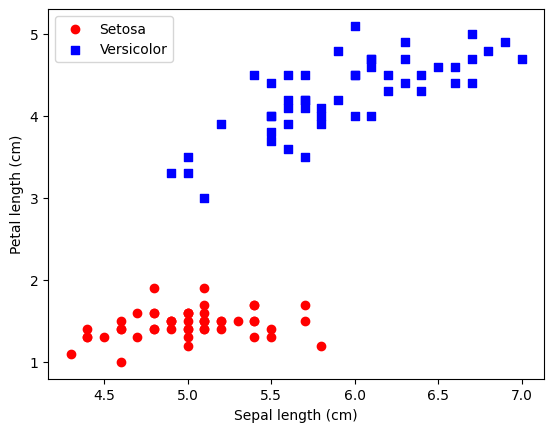

In [6]:
plt.scatter(X[:50, 0], X[0:50, 1], color="red", marker="o", label="Setosa")
plt.scatter(X[50:, 0], X[50:, 1], color="blue", marker="s", label="Versicolor")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.legend(loc="upper left")
plt.show()

In this two-dimensional feature subspace, we can see tha a linear decision boundary should be sufficient to separate **setosa** from **versicolor** flowers. Thus, a linear classifier such as the perceptron should be able to classify the flowers in this dataset perfectly.

In [7]:
ppn = Perceptron(alpha=0.0001, max_iter=1000)
ppn.fit(X, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


### A Note on Scikit-Learn's Perceptron

If you are using the official `sklearn.linear_model.Perceptron` (which I'm using), it does not actually have a `.errors_` attribute by default. That specific attribute name is usually from the custom Perceptron implementation in the famous book **"Python Machine Learning"** by **Sebastian Raschka** or in my own implementation of [Perceptron](https://github.com/joshiayush/ai/blob/master/ai/linear_model/perceptron.py) algorithm.

What we can do here is check the exact point where the model converged, check if the `ppn.n_iter_` is less than the `max_iter`.

In [8]:
print(f"Total epochs run: {ppn.n_iter_}")

Total epochs run: 7


As we can see, our perceptron converged after the seventh epoch and should now be able to classify the training examples perfectly. Let's implement a small convenience function to visualize the decision boundaries for two-dimensional datasets.

In [ ]:
def plot_decision_regions(
    X: np.ndarray, y: np.ndarray, classifier: Perceptron, resolution: float = 0.02
) -> None:
    markers = ("o", "s", "^", "v", "<")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )

    labels = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    labels = labels.reshape(xx1.shape)

    plt.contourf(xx1, xx2, labels, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black",
        )

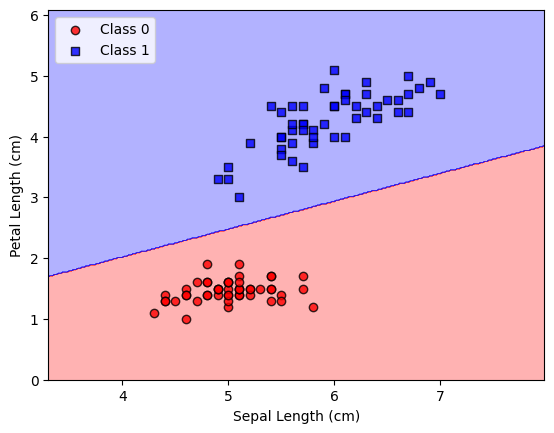

In [13]:
plot_decision_regions(X, y, ppn)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend(loc="upper left")
plt.show()